In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.seasonal import seasonal_decompose


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving cleaned_customer_data.csv to cleaned_customer_data.csv
Saving cleaned_inventory_data.csv to cleaned_inventory_data.csv
Saving cleaned_product_data.csv to cleaned_product_data.csv
Saving cleaned_sales_data.csv to cleaned_sales_data.csv


In [ ]:
sales_df = pd.read_csv("cleaned_sales_data.csv")

print("Dataset Shape:", sales_df.shape)
print("\nColumns:")
print(sales_df.columns.tolist())

Dataset Shape: (5000, 19)

Columns:
['Order_ID', 'Order_Date', 'Customer_ID', 'Product_ID', 'Product_Name', 'Category', 'Quantity', 'Selling_Price', 'Cost_Price', 'Discount_Percent', 'Gross_Sales', 'Discount_Amount', 'Revenue', 'Total_Cost', 'Profit', 'Profit_Margin_Percent', 'Payment_Mode', 'Sales_Channel', 'City']


In [ ]:
sales_df["Order_Date"] = pd.to_datetime(sales_df["Order_Date"])

sales_df = sales_df.sort_values("Order_Date")

monthly_data = (
    sales_df
    .groupby(sales_df["Order_Date"].dt.to_period("M"))["Revenue"]
    .sum()
    .reset_index()
)

monthly_data["Order_Date"] = monthly_data["Order_Date"].dt.to_timestamp()

print("Monthly Time-Series Shape:", monthly_data.shape)
print("\nMonthly Time-Series Data:")
print(monthly_data.head())

Monthly Time-Series Shape: (30, 2)

Monthly Time-Series Data:
  Order_Date    Revenue
0 2024-01-01  1057367.5
1 2024-02-01   864723.5
2 2024-03-01  1059854.5
3 2024-04-01  1348028.0
4 2024-05-01  1027435.0


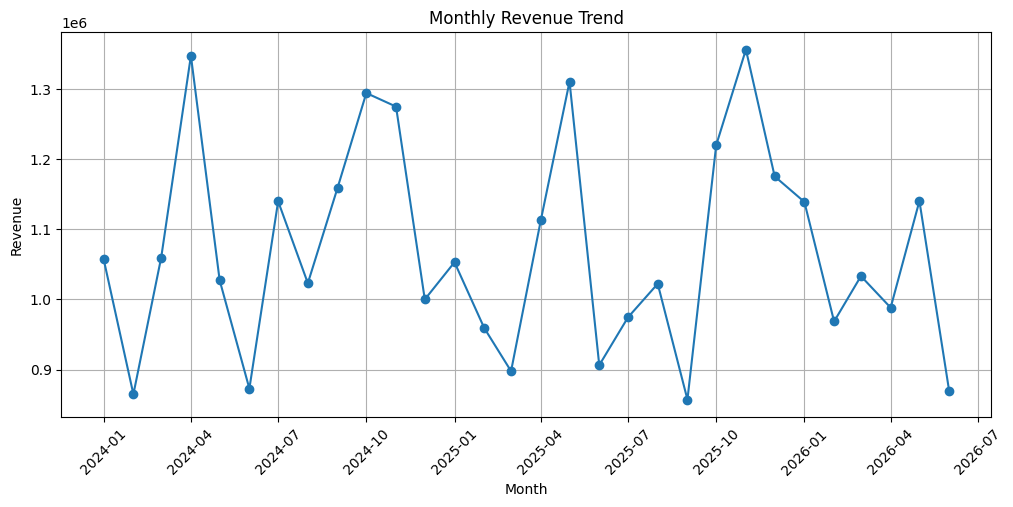

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data["Order_Date"],
    monthly_data["Revenue"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

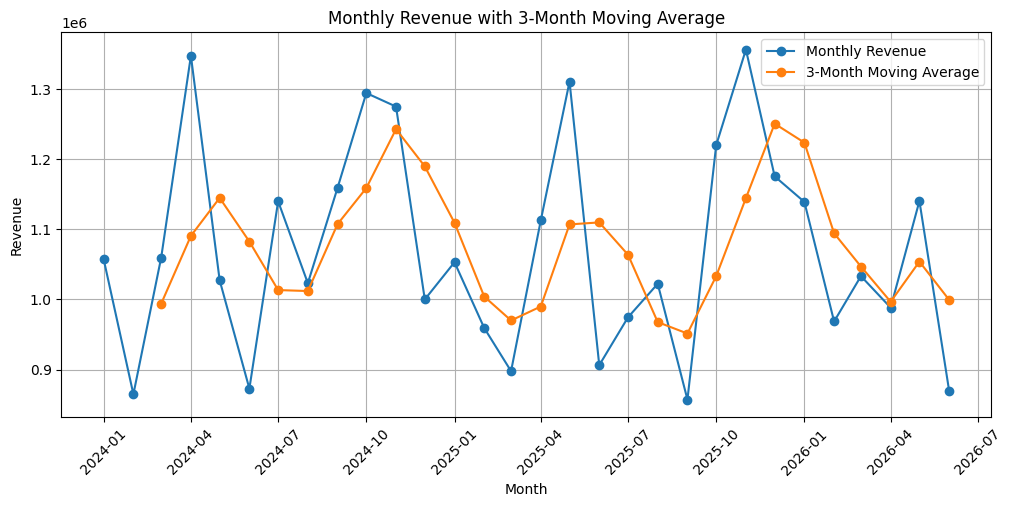

In [ ]:
monthly_data["3_Month_Moving_Average"] = (
    monthly_data["Revenue"].rolling(window=3).mean()
)

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_data["Order_Date"],
    monthly_data["Revenue"],
    marker="o",
    label="Monthly Revenue"
)

plt.plot(
    monthly_data["Order_Date"],
    monthly_data["3_Month_Moving_Average"],
    marker="o",
    label="3-Month Moving Average"
)

plt.title("Monthly Revenue with 3-Month Moving Average")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

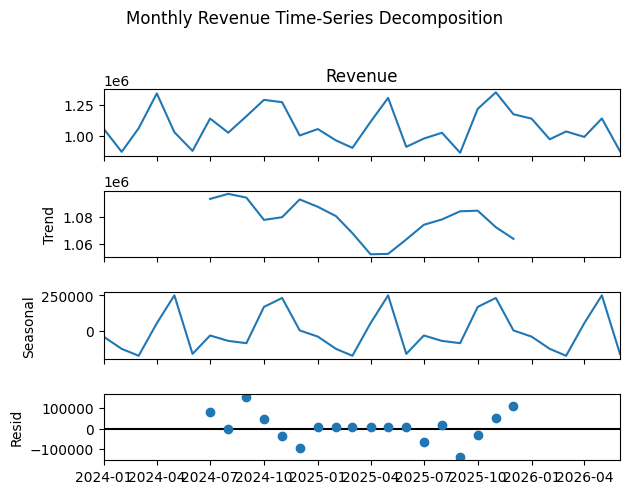

In [ ]:
time_series = monthly_data.set_index("Order_Date")["Revenue"]

decomposition = seasonal_decompose(
    time_series,
    model="additive",
    period=12
)

decomposition.plot()

plt.suptitle(
    "Monthly Revenue Time-Series Decomposition",
    y=1.02
)

plt.tight_layout()
plt.show()

In [ ]:
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

components_df = pd.DataFrame({
    "Revenue": time_series,
    "Trend": trend,
    "Seasonal": seasonal,
    "Residual": residual
})

print("Time-Series Components:")
print(components_df.round(2).head(15))


Time-Series Components:
              Revenue       Trend   Seasonal   Residual
Order_Date                                             
2024-01-01  1057367.5         NaN  -41822.32        NaN
2024-02-01   864723.5         NaN -128794.99        NaN
2024-03-01  1059854.5         NaN -177792.93        NaN
2024-04-01  1348028.0         NaN   53144.53        NaN
2024-05-01  1027435.0         NaN  251040.64        NaN
2024-06-01   872715.0         NaN -164575.28        NaN
2024-07-01  1140245.0  1093447.33  -33895.01   80692.68
2024-08-01  1023276.0  1097215.02  -72291.25   -1647.77
2024-09-01  1159452.5  1094398.29  -88507.80  153562.01
2024-10-01  1294800.0  1077844.25  168856.67   48099.08
2024-11-01  1275461.0  1079867.12  232570.87  -36977.00
2024-12-01  1000087.5  1093081.69    2066.87  -95061.06
2025-01-01  1053212.5  1087573.29  -41822.32    7461.53
2025-02-01   959303.0  1080636.46 -128794.99    7461.53
2025-03-01   897673.5  1068004.90 -177792.93    7461.53


In [ ]:
residual_std = residual.dropna().std()

anomaly_threshold = 2 * residual_std

anomalies = components_df[
    components_df["Residual"].abs() > anomaly_threshold
].dropna()

print("Anomaly Threshold:", round(anomaly_threshold, 2))

print("\nDetected Revenue Anomalies:")
print(anomalies[["Revenue", "Trend", "Seasonal", "Residual"]].round(2))

print("\nNumber of Anomalies Detected:", len(anomalies))

Anomaly Threshold: 138781.6

Detected Revenue Anomalies:
              Revenue       Trend  Seasonal   Residual
Order_Date                                            
2024-09-01  1159452.5  1094398.29  -88507.8  153562.01

Number of Anomalies Detected: 1


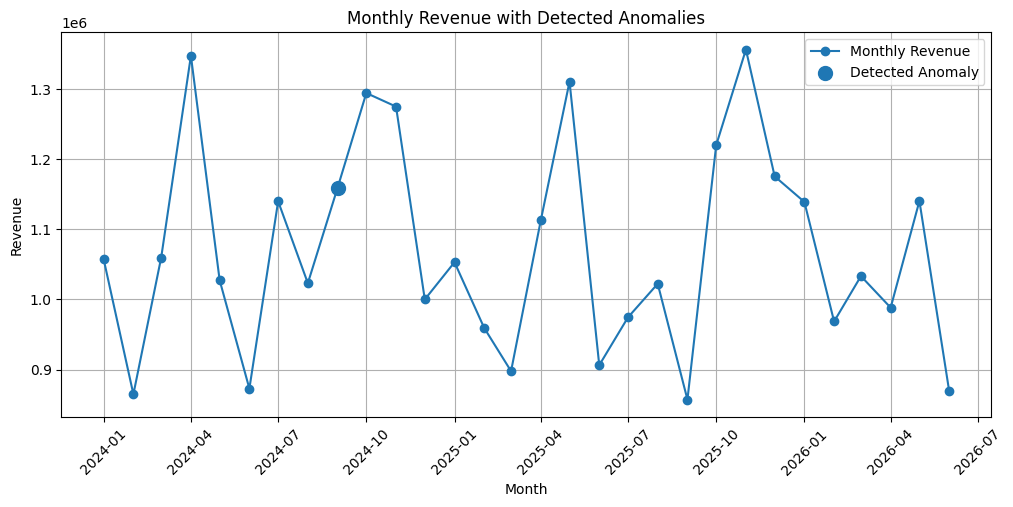

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(
    components_df.index,
    components_df["Revenue"],
    marker="o",
    label="Monthly Revenue"
)

plt.scatter(
    anomalies.index,
    anomalies["Revenue"],
    s=100,
    label="Detected Anomaly"
)

plt.title("Monthly Revenue with Detected Anomalies")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
prophet_data = monthly_data[["Order_Date", "Revenue"]].copy()

prophet_data = prophet_data.rename(
    columns={
        "Order_Date": "ds",
        "Revenue": "y"
    }
)

print("Prophet Dataset:")
print(prophet_data.head())

print("\nShape:", prophet_data.shape)

Prophet Dataset:
          ds          y
0 2024-01-01  1057367.5
1 2024-02-01   864723.5
2 2024-03-01  1059854.5
3 2024-04-01  1348028.0
4 2024-05-01  1027435.0

Shape: (30, 2)


In [ ]:
!pip install prophet -q



In [ ]:
from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

prophet_model.fit(prophet_data)

print("Prophet forecasting model trained successfully.")

INFO:prophet:n_changepoints greater than number of observations. Using 23.


Prophet forecasting model trained successfully.


In [ ]:
future = prophet_model.make_future_dataframe(
    periods=6,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast_result = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].tail(6)

print("Next 6 Months Revenue Forecast:")
print(forecast_result.round(2))

Next 6 Months Revenue Forecast:
           ds        yhat  yhat_lower  yhat_upper
30 2026-06-30   859440.03   793110.62   928675.10
31 2026-07-31  1560057.65  1496438.69  1628533.97
32 2026-08-31  -269298.42  -331412.39  -193386.25
33 2026-09-30  1061147.57   992002.40  1129505.55
34 2026-10-31  1698743.98  1629723.19  1768230.64
35 2026-11-30  1753062.76  1690389.65  1817533.76


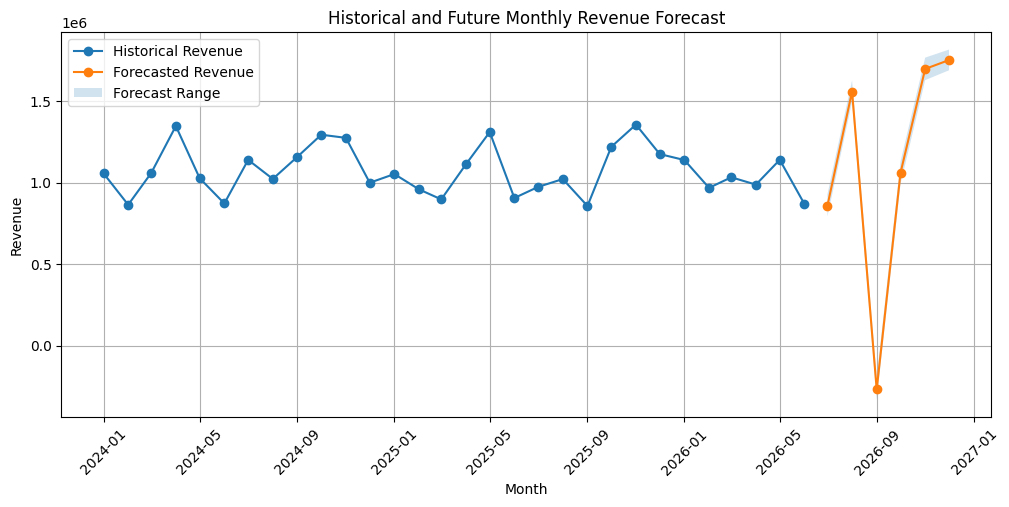

In [19]:
plt.figure(figsize=(12, 5))

plt.plot(
    prophet_data["ds"],
    prophet_data["y"],
    marker="o",
    label="Historical Revenue"
)

future_forecast = forecast.tail(6)

plt.plot(
    future_forecast["ds"],
    future_forecast["yhat"],
    marker="o",
    label="Forecasted Revenue"
)

plt.fill_between(
    future_forecast["ds"],
    future_forecast["yhat_lower"],
    future_forecast["yhat_upper"],
    alpha=0.2,
    label="Forecast Range"
)

plt.title("Historical and Future Monthly Revenue Forecast")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [21]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Split data into training and testing periods
train_data = prophet_data.iloc[:-6].copy()
test_data = prophet_data.iloc[-6:].copy()

# Train Prophet without yearly seasonality
evaluation_model = Prophet(
    yearly_seasonality=False,
    weekly_seasonality=False,
    daily_seasonality=False
)

evaluation_model.fit(train_data)

# Forecast the testing period
test_future = evaluation_model.make_future_dataframe(
    periods=6,
    freq="ME"
)

test_forecast = evaluation_model.predict(test_future)

# Get predictions for the six test months
predicted_test = test_forecast.tail(6)["yhat"].values
actual_test = test_data["y"].values

# Calculate accuracy metrics
mae = mean_absolute_error(actual_test, predicted_test)
rmse_ts = np.sqrt(mean_squared_error(actual_test, predicted_test))

print("===== Time-Series Forecast Accuracy =====")
print(f"MAE: ₹{mae:,.2f}")
print(f"RMSE: ₹{rmse_ts:,.2f}")

INFO:prophet:n_changepoints greater than number of observations. Using 18.


===== Time-Series Forecast Accuracy =====
MAE: ₹110,537.47
RMSE: ₹136,952.79


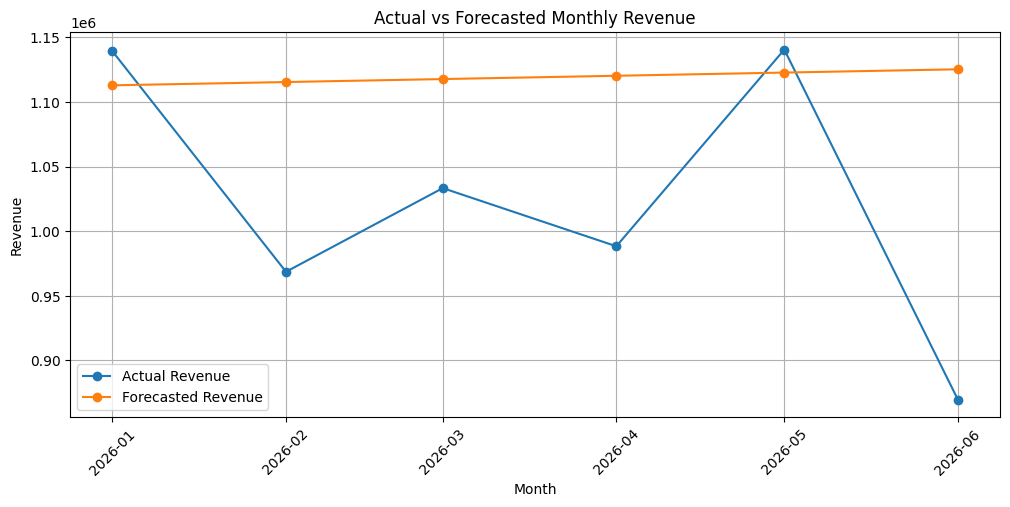

In [22]:
plt.figure(figsize=(12, 5))

plt.plot(
    test_data["ds"],
    actual_test,
    marker="o",
    label="Actual Revenue"
)

plt.plot(
    test_data["ds"],
    predicted_test,
    marker="o",
    label="Forecasted Revenue"
)

plt.title("Actual vs Forecasted Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True)

plt.show()

In [23]:
forecasted_revenue = predicted_test

print("===== Time-Series Business Insights =====\n")

print(f"Average Actual Revenue: ₹{np.mean(actual_test):,.2f}")
print(f"Average Forecasted Revenue: ₹{np.mean(forecasted_revenue):,.2f}")

print(f"\nMinimum Actual Revenue: ₹{np.min(actual_test):,.2f}")
print(f"Maximum Actual Revenue: ₹{np.max(actual_test):,.2f}")

print("\nBusiness Interpretation:")
print("1. Time-series forecasting helps estimate future revenue from historical patterns.")
print("2. Revenue trends can support sales target and resource planning.")
print("3. Forecast information can help businesses prepare inventory for expected demand.")
print("4. Unusual increases or decreases in revenue should be investigated for possible")
print("   promotions, demand changes, operational issues, or other business factors.")
print("5. Forecasts should be treated as decision-support information rather than guaranteed outcomes.")


===== Time-Series Business Insights =====

Average Actual Revenue: ₹1,023,320.08
Average Forecasted Revenue: ₹1,119,132.18

Minimum Actual Revenue: ₹869,654.50
Maximum Actual Revenue: ₹1,140,631.50

Business Interpretation:
1. Time-series forecasting helps estimate future revenue from historical patterns.
2. Revenue trends can support sales target and resource planning.
3. Forecast information can help businesses prepare inventory for expected demand.
4. Unusual increases or decreases in revenue should be investigated for possible
   promotions, demand changes, operational issues, or other business factors.
5. Forecasts should be treated as decision-support information rather than guaranteed outcomes.


In [24]:
print("===== Week 5 Final Validation =====\n")

print("✓ Time-series data prepared")
print("✓ Monthly revenue aggregation completed")
print("✓ Revenue trend analysis completed")
print("✓ Moving average trend analysis completed")
print("✓ Time-series decomposition completed")
print("✓ Trend and seasonality analyzed")
print("✓ Revenue anomaly detection completed")
print("✓ Statsmodels analysis completed")
print("✓ Prophet forecasting completed")
print("✓ Future revenue forecast generated")
print("✓ Forecast accuracy evaluated using MAE and RMSE")
print("✓ Actual vs forecast comparison completed")
print("✓ Business insights and recommendations generated")

print("\nWeek 5 Advanced Analytics and Time-Series Analysis task completed successfully!")

===== Week 5 Final Validation =====

✓ Time-series data prepared
✓ Monthly revenue aggregation completed
✓ Revenue trend analysis completed
✓ Moving average trend analysis completed
✓ Time-series decomposition completed
✓ Trend and seasonality analyzed
✓ Revenue anomaly detection completed
✓ Statsmodels analysis completed
✓ Prophet forecasting completed
✓ Future revenue forecast generated
✓ Forecast accuracy evaluated using MAE and RMSE
✓ Actual vs forecast comparison completed
✓ Business insights and recommendations generated

Week 5 Advanced Analytics and Time-Series Analysis task completed successfully!
